In [1]:
# -----------------------------
# CONFIG: choose dataset version
# -----------------------------

VERSION = "50000"  

DATA_DIR = f"./out_{VERSION}"

ACOUSTIC_FILE = f"{DATA_DIR}/acoustic_{VERSION}.parquet"
UMAP_FILE     = f"{DATA_DIR}/acoustic_umap_{VERSION}.parquet"
BEHAV_FILE    = f"{DATA_DIR}/behavior_edges_{VERSION}.parquet"
TDA_FILE      = f"{DATA_DIR}/tda_summary_{VERSION}.json"
META_FILE     = "./out_/artist_terms_.parquet"

print("Using dataset version:", VERSION)
print("Acoustic:", ACOUSTIC_FILE)
print("UMAP:", UMAP_FILE)
print("Behavior:", BEHAV_FILE)
print("TDA summary:", TDA_FILE)

Using dataset version: 50000
Acoustic: ./out_50000/acoustic_50000.parquet
UMAP: ./out_50000/acoustic_umap_50000.parquet
Behavior: ./out_50000/behavior_edges_50000.parquet
TDA summary: ./out_50000/tda_summary_50000.json


In [2]:
import pandas as pd
import networkx as nx
import numpy as np

# === Load your behavioral graph ===
edges = pd.read_parquet(BEHAV_FILE)  # has columns: a, b, w

# Build NetworkX graph with positive "distance" weights
G = nx.Graph()
for _, row in edges.iterrows():
    a, b, w = row["a"], row["b"], float(row["w"])
    # teacher code expects smaller numbers = stronger
    dist = 1.0 / w     
    G.add_edge(a, b, weight=dist)

print("Nodes:", len(G.nodes()))
print("Edges:", len(G.edges()))

Nodes: 19151
Edges: 2902517


In [3]:
import numpy as np
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import shortest_path
import matplotlib.pyplot as plt


def reconstruct_cycle(dist_mat, cocycle, t, one_based=False):
    n = dist_mat.shape[0]
    
    # Filter cocycle by threshold and process edges
    cocycle = [edge for edge in cocycle if dist_mat[int(edge[0]), int(edge[1])] <= t]
    removed = set()
    
    for a, b, coeff in cocycle:
        if coeff != 0:
            if one_based:
                a, b = int(a) - 1, int(b) - 1
            else:
                a, b = int(a), int(b)
            removed.add(tuple(sorted((a, b))))
    
    removed_edges = list(removed)
    if not removed_edges:
        return None
    
    # Build sparse adjacency matrix (excluding removed edges)
    # Use CSR format for efficient shortest path computation
    row_indices = []
    col_indices = []
    data = []
    
    for i in range(n):
        for j in range(i + 1, n):
            if dist_mat[i, j] <= t and (i, j) not in removed:
                # Add both directions for undirected graph
                row_indices.extend([i, j])
                col_indices.extend([j, i])
                data.extend([dist_mat[i, j], dist_mat[i, j]])
    
    # Create sparse matrix
    adj_matrix = csr_matrix((data, (row_indices, col_indices)), shape=(n, n))
    
    best_cycle = None
    best_weight = float('inf')
    
    # For each removed edge, find shortest path
    for u, v in removed_edges:
        # Compute shortest path from u to v
        distances, predecessors = shortest_path(
            adj_matrix, indices=u, return_predecessors=True
        )
        
        if distances[v] == np.inf:
            continue  # No path exists
        
        # Reconstruct path from predecessors
        path = []
        current = v
        while current != u:
            prev = predecessors[current]
            if prev == -9999:  # No path
                break
            path.append((min(current, prev), max(current, prev)))
            current = prev
        
        if current == u:  # Successfully reconstructed path
            # Add the removed edge to complete the cycle
            cycle = path + [tuple(sorted((u, v)))]
            weight = sum(dist_mat[a, b] for a, b in cycle)
            
            if weight < best_weight:
                best_weight = weight
                best_cycle = cycle
    
    return [(int(u), int(v)) for (u, v) in best_cycle] 

Selected H1 feature:
  birth = 1.0
  death = 2.0
  persistence = 1.0

Cycle sizes:
  At birth: 4
  At mid: 4
  At death: 3


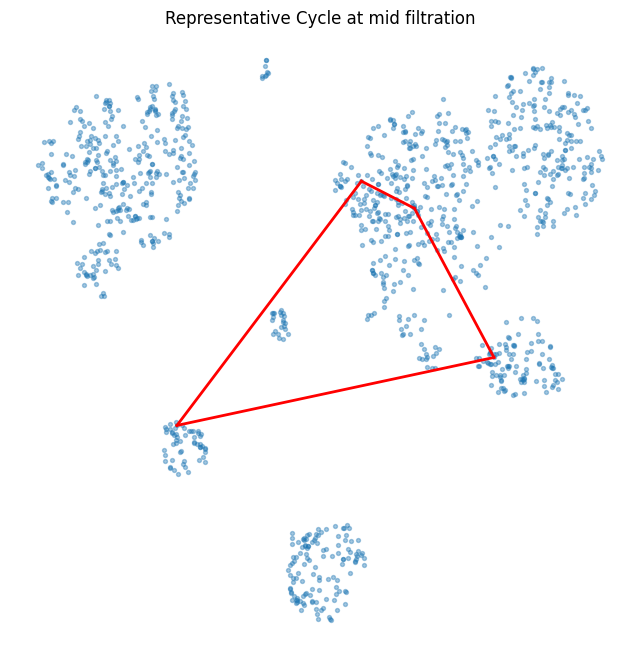

In [8]:
from ripser import ripser
import numpy as np

# ---- 1. Make sure you already have behavioral or acoustic distance matrix ----
# Example: using behavioral TDA distance D_be from feature_pipeline output
dist_mat = np.load("./out_50000/D_be_50000.npy")   # or D_ac_1000.npy

# ---- 2. Compute persistence with cocycles ----
result = ripser(dist_mat, distance_matrix=True, maxdim=1, do_cocycles=True)

H1_dgm = result['dgms'][1]
H1_cocycles = result['cocycles'][1]

# ---- 3. Select the most persistent H1 feature ----
lengths = H1_dgm[:,1] - H1_dgm[:,0]
idx = np.argmax(lengths)

birth = float(H1_dgm[idx,0])
death = float(H1_dgm[idx,1])
mid = (birth + death)/2

cocycle = H1_cocycles[idx]

print("Selected H1 feature:")
print("  birth =", birth)
print("  death =", death)
print("  persistence =", death - birth)

# ---- 4. Use your teacher's function to reconstruct cycles ----
cycle_birth = reconstruct_cycle(dist_mat, cocycle, t=birth)
cycle_mid   = reconstruct_cycle(dist_mat, cocycle, t=mid)
cycle_death = reconstruct_cycle(dist_mat, cocycle, t=death)

print("\nCycle sizes:")
print("  At birth:",   len(cycle_birth) if cycle_birth else 0)
print("  At mid:",     len(cycle_mid) if cycle_mid else 0)
print("  At death:",   len(cycle_death) if cycle_death else 0)

# ---- 5. Optionally visualize (if your acoustic UMAP is available) ----
import matplotlib.pyplot as plt
import pandas as pd

umap_df = pd.read_parquet("./out_50000/acoustic_umap_50000.parquet")
pos = {sid:(x,y) for sid,x,y in zip(umap_df['song_id'], umap_df['x'], umap_df['y'])}

# Map TDA indices → song IDs
# df_tda (subset) is saved at: OUTDIR / f'tda_subset_{TAG}.parquet'
df_tda = pd.read_parquet("./out_50000/tda_subset_50000.parquet")
idx_to_sid = df_tda['song_id'].tolist()

def plot_cycle(edges, title):
    plt.figure(figsize=(8,8))
    xs = [pos[idx_to_sid[i]][0] for i in range(len(idx_to_sid))]
    ys = [pos[idx_to_sid[i]][1] for i in range(len(idx_to_sid))]
    plt.scatter(xs, ys, s=8, alpha=0.4)

    for u,v in edges:
        x1,y1 = pos[idx_to_sid[u]]
        x2,y2 = pos[idx_to_sid[v]]
        plt.plot([x1,x2], [y1,y2], color='red', linewidth=2)

    plt.title(title)
    plt.axis("off")
    plt.show()

if cycle_mid:
    plot_cycle(cycle_mid, "Representative Cycle at mid filtration")

Behavioral distance matrix shape: (1200, 1200)
Selected H1 loop:
 birth = 1.0
 death = 2.0
 persistence = 1.0


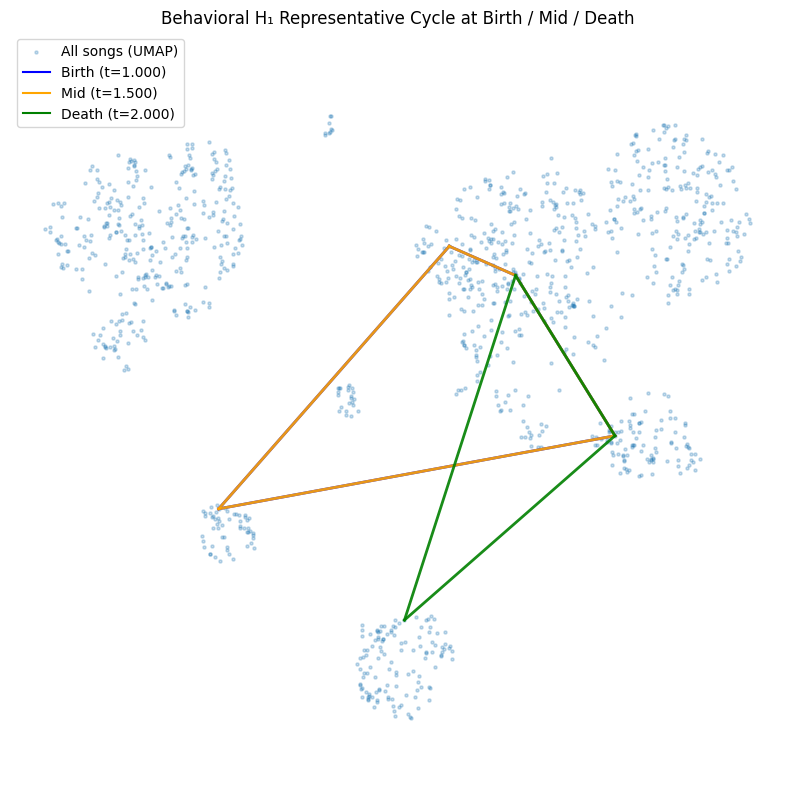

Cycle sizes: {1.0: 4, 1.5: 4, 2.0: 3}


In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from ripser import ripser
from scipy.spatial.distance import cdist

# ---------------------------------------------------------
# 1. Load behavioral distance matrix (same one used for TDA)
# ---------------------------------------------------------
D_be = np.load("./out_50000/D_be_50000.npy")
print("Behavioral distance matrix shape:", D_be.shape)

# ---------------------------------------------------------
# 2. Compute persistence with cocycles on BEHAVIOR space
# ---------------------------------------------------------
result = ripser(D_be, distance_matrix=True, maxdim=1, do_cocycles=True)
H1_dgm = result["dgms"][1]
H1_cocycles = result["cocycles"][1]

# choose the most persistent H1 feature
lengths = H1_dgm[:,1] - H1_dgm[:,0]
idx = np.argmax(lengths)

birth = float(H1_dgm[idx,0])
death = float(H1_dgm[idx,1])
mid   = 0.5 * (birth + death)
cocycle = H1_cocycles[idx]

print("Selected H1 loop:")
print(" birth =", birth)
print(" death =", death)
print(" persistence =", death - birth)

# ---------------------------------------------------------
# 3. Load TDA subset + UMAP coords to visualize cycle
# ---------------------------------------------------------
umap_df = pd.read_parquet("./out_50000/acoustic_umap_50000.parquet")
tda_df  = pd.read_parquet("./out_50000/tda_subset_50000.parquet")

# join UMAP coordinates onto the TDA subset
df = tda_df.merge(umap_df[["song_id","x","y"]], on="song_id", how="left")

# extract UMAP coordinates for plotting
X = df["x"].to_numpy()
Y = df["y"].to_numpy()
pos = np.column_stack([X, Y])

# map TDA index → song_id
idx_to_sid = df["song_id"].tolist()

# ---------------------------------------------------------
# 4. Reconstruct cycles at birth, mid, death
# ---------------------------------------------------------
cycle_birth = reconstruct_cycle(D_be, cocycle, t=birth)
cycle_mid   = reconstruct_cycle(D_be, cocycle, t=mid)
cycle_death = reconstruct_cycle(D_be, cocycle, t=death)

cycles = {
    birth: cycle_birth,
    mid:   cycle_mid,
    death: cycle_death
}

# ---------------------------------------------------------
# 5. Plot cycles (like your teacher)
# ---------------------------------------------------------
colors = ["blue", "orange", "green"]
labels = ["Birth", "Mid", "Death"]

plt.figure(figsize=(10,10))
plt.scatter(X, Y, s=5, alpha=0.25, label="All songs (UMAP)")

for ci, (t, edges) in enumerate(cycles.items()):
    if edges is None: 
        continue
    for u, v in edges:
        x1, y1 = pos[u]
        x2, y2 = pos[v]
        plt.plot([x1,x2],[y1,y2], 
                 color=colors[ci], 
                 linewidth=2, alpha=0.9)
    plt.plot([],[],color=colors[ci],label=f"{labels[ci]} (t={t:.3f})")

plt.legend()
plt.title("Behavioral H₁ Representative Cycle at Birth / Mid / Death")
plt.axis("equal")
plt.axis("off")
plt.show()

print("Cycle sizes:", {round(t,4): len(c) if c else 0 for t,c in cycles.items()})

In [16]:
import pandas as pd

# TDA subset: rows correspond directly to the distance-matrix indices
df_tda = pd.read_parquet("./out_50000/tda_subset_50000.parquet")

idx_to_sid = df_tda["song_id"].tolist()

acoustic = pd.read_parquet("./out_50000/acoustic_50000.parquet")

title_map  = acoustic.set_index("song_id")["title"].to_dict()
artist_map = acoustic.set_index("song_id")["artist"].to_dict()

def cycle_to_song_info(cycle_edges, label):
    rows = []
    for u, v in cycle_edges:
        sid_u = idx_to_sid[int(u)]
        sid_v = idx_to_sid[int(v)]

        rows.append({
            "cycle_stage": label,
            "u_idx": int(u),
            "u_song_id": sid_u,
            "u_title": title_map.get(sid_u, "Unknown"),
            "u_artist": artist_map.get(sid_u, "Unknown"),

            "v_idx": int(v),
            "v_song_id": sid_v,
            "v_title": title_map.get(sid_v, "Unknown"),
            "v_artist": artist_map.get(sid_v, "Unknown"),
        })
    return pd.DataFrame(rows)

tables = []

if cycle_birth is not None:
    tables.append(cycle_to_song_info(cycle_birth, "birth"))

if cycle_mid is not None:
    tables.append(cycle_to_song_info(cycle_mid, "mid"))

if cycle_death is not None:
    tables.append(cycle_to_song_info(cycle_death, "death"))

cycle_songs_df = pd.concat(tables, ignore_index=True)

cycle_songs_df

,cycle_stage,u_idx,u_song_id,u_title,u_artist,v_idx,v_song_id,v_title,v_artist
0,birth,233,SOMJIOC12AB018514F,My Special Angel,Frankie Avalon,435,SOQFTOE12A8C13A6A8,Ain't Misbehavin' (I'm Savin' My Love For You)...,Leon Redbone
1,birth,369,SOPWDAT12AB0181767,Walk On Me,Ben Kweller,435,SOQFTOE12A8C13A6A8,Ain't Misbehavin' (I'm Savin' My Love For You)...,Leon Redbone
2,birth,31,SOIQMOI12A8C1377DB,A Train Not Running,Chris Knight,369,SOPWDAT12AB0181767,Walk On Me,Ben Kweller
3,birth,31,SOIQMOI12A8C1377DB,A Train Not Running,Chris Knight,233,SOMJIOC12AB018514F,My Special Angel,Frankie Avalon
4,mid,233,SOMJIOC12AB018514F,My Special Angel,Frankie Avalon,435,SOQFTOE12A8C13A6A8,Ain't Misbehavin' (I'm Savin' My Love For You)...,Leon Redbone
5,mid,369,SOPWDAT12AB0181767,Walk On Me,Ben Kweller,435,SOQFTOE12A8C13A6A8,Ain't Misbehavin' (I'm Savin' My Love For You)...,Leon Redbone
6,mid,31,SOIQMOI12A8C1377DB,A Train Not Running,Chris Knight,369,SOPWDAT12AB0181767,Walk On Me,Ben Kweller
7,mid,31,SOIQMOI12A8C1377DB,A Train Not Running,Chris Knight,233,SOMJIOC12AB018514F,My Special Angel,Frankie Avalon
8,death,233,SOMJIOC12AB018514F,My Special Angel,Frankie Avalon,751,SOHVGWT12A8C136B3C,Growin' Up,Bruce Springsteen
9,death,31,SOIQMOI12A8C1377DB,A Train Not Running,Chris Knight,751,SOHVGWT12A8C136B3C,Growin' Up,Bruce Springsteen
